# IY021 – SimCLR Embeddings + SVM: Dual-Channel (mCherry + GFP) Experimental Data

**Goal:** Classify cells by **TF × glucose condition** (6 classes: Nrg1/Rtg1 × 2%/0.1%/0.01% glucose) using frozen SimCLR backbones applied to both channels independently. mCherry and GFP embeddings are concatenated before the SVM.

Chance level = 1/6 ≈ 16.7%.

**Data:** `EXP-25-IY013/transformed_exp_time_series_data_v2/`

In [1]:
import sys
import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from tqdm import tqdm

sys.path.insert(0, str(Path("/home/ianyang/stochastic_simulations/src").resolve()))
from models.ssl_transformer import SSL_Transformer

sys.path.insert(0, "/home/ianyang/wela/src")
sys.path.insert(0, "/home/ianyang/alibylite/src")

np.random.seed(42)
torch.manual_seed(42)

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EXP_DIR = Path("/home/ianyang/stochastic_simulations/experiments")
META_COLS = ["id", "group", "experiment"]
print(f"Device: {DEVICE}")

Device: cuda


## 1. Load Experimental Data & Assign Labels

In [2]:
# Verify TF mapping per experiment using get_exp_summary
import glob as _glob
from wela.get_exp_conditions import get_exp_summary

_BASE = "/home/ianyang/alibylite/high_quality_data_analysis"
_OMID_MAP = {
    "19316": "19316_2020_10_26_steadystate_glucose_144m_2w2_00",
    "19566": "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01",
    "20213": "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00",
}
print("TF mapping verification via get_exp_summary")
print("=" * 65)
for prefix, omid in _OMID_MAP.items():
    acq = _glob.glob(f"{_BASE}/{omid}/*Acq.txt")[0]
    log = _glob.glob(f"{_BASE}/{omid}/*log.txt")[0]
    summary_df, tf_df, _ = get_exp_summary(acq, log)
    pump = summary_df["pump_contents"].values[0]
    print(f"\n{prefix}  pump={pump}")
    if not tf_df.empty:
        print(tf_df.to_string(index=False))

TF mapping verification via get_exp_summary
=== EXPERIMENT SUMMARY ===

📸 IMAGING SETUP (from acquisition file):
• Channels: ['Brightfield', 'GFP', 'mCherry']
• Exposure times: [30, 30, 100] ms
• Camera EM gain: 270

⏱️ TIME-LAPSE SETTINGS:
• Time interval: 120 seconds (2.0 minutes)
• Number of timepoints: 540
• Total experiment time: 64800 seconds (18.0 hours)

🧪 MICROFLUIDICS SETUP:
• Number of pumps: 2
• Pump rates: [[0.0], [4.0]]
• Pump contents: ['2% glucose in SC', '2% glucose in SC']
• Number of switches: 1
• Switch volumes: 50
• Switch rates: 100
• Switch times: [180]

🔬 MICROSCOPE SETUP (from log file):
• Microscope: Batgirl
• Date: 2020-10-25 00:00:00
• Experiment start time: 2020-10-25 17:09:13
• Capture of the first image: 2020-10-25 17:09:14
• MultiDGUI commit: 29bfe736500ed3f8be9c19585bee78cc67ceae26
• Experimental details: Aim:   Strain:   Comments:   Strains 1344 and 1346 were both labelled 1346 in the subculturing so not sure which is which.

💾 OMERO INFORMATION:
• Pro

In [3]:
DATA_DIR = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY013/transformed_exp_time_series_data_v2")
META_COLS = ["id", "group", "experiment"]

# Each entry: (mCherry_stem, GFP_stem, label, glucose_pct, TF)
# Label = TF × glucose condition (6 classes)
# Exclusions: 19554 (Mig1/unknown TFs), 19566/group_1344 (ambiguous TF), Cat8 (only 2 of 3 conditions)
FILE_PAIRS = [
    # Nrg1 strain (group 1346)
    ("19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1346_4_mCherry_time_series",
     "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1346_4_GFP_time_series",
     0, "2%",    "Nrg1"),
    ("19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1346_mCherry_time_series",
     "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1346_GFP_time_series",
     1, "0.1%",  "Nrg1"),
    ("20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1346_mCherry_time_series",
     "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1346_GFP_time_series",
     2, "0.01%", "Nrg1"),
    # Rtg1 strain (group 1347)
    ("19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1347_mCherry_time_series",
     "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1347_GFP_time_series",
     3, "2%",    "Rtg1"),
    ("19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1347_mCherry_time_series",
     "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1347_GFP_time_series",
     4, "0.1%",  "Rtg1"),
    ("20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1347_mCherry_time_series",
     "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1347_GFP_time_series",
     5, "0.01%", "Rtg1"),
]

label_names = {
    0: "Nrg1 @ 2% glc",    1: "Nrg1 @ 0.1% glc",  2: "Nrg1 @ 0.01% glc",
    3: "Rtg1 @ 2% glc",    4: "Rtg1 @ 0.1% glc",  5: "Rtg1 @ 0.01% glc",
}

# ── Load & merge channels per cell ──────────────────────────────────────────
all_m, all_g, all_y, all_strain = [], [], [], []

for mc_stem, gfp_stem, label, glc, tf in FILE_PAIRS:
    df_m = pd.read_csv(DATA_DIR / f"{mc_stem}.csv")
    df_g = pd.read_csv(DATA_DIR / f"{gfp_stem}.csv")

    tc_m = [c for c in df_m.columns if c not in META_COLS]
    tc_g = [c for c in df_g.columns if c not in META_COLS]

    # Keep only cells present in both channels
    common = set(df_m["id"]) & set(df_g["id"])
    df_m = df_m[df_m["id"].isin(common)].set_index("id").sort_index()
    df_g = df_g[df_g["id"].isin(common)].set_index("id").sort_index()

    all_m.append(df_m[tc_m].values.astype(float))
    all_g.append(df_g[tc_g].values.astype(float))
    all_y.extend([label] * len(common))
    all_strain.extend([tf] * len(common))
    print(f"  {tf} (GFP) / Msn2 (mCherry) @ {glc:>5s} glc  "
          f"— {len(common)} paired cells  "
          f"[mCherry: {len(tc_m)} tp, GFP: {len(tc_g)} tp]")

# Truncate each channel to its own global minimum across all files
min_tp_m = min(a.shape[1] for a in all_m)
min_tp_g = min(a.shape[1] for a in all_g)
print(f"\nTruncating: mCherry → {min_tp_m} tp, GFP → {min_tp_g} tp")

all_m = [a[:, :min_tp_m] for a in all_m]
all_g = [a[:, :min_tp_g] for a in all_g]

# Concatenate channels: [mCherry | GFP]
X_m   = np.vstack(all_m)   # (N, min_tp_m)  — kept separate for plotting
X_g   = np.vstack(all_g)   # (N, min_tp_g)
X_raw = np.concatenate([X_m, X_g], axis=1)   # (N, min_tp_m + min_tp_g)
y       = np.array(all_y,     dtype=int)
strains = np.array(all_strain)

print(f"Dataset: {X_raw.shape[0]} cells × {X_raw.shape[1]} combined timepoints "
      f"({min_tp_m} mCherry + {min_tp_g} GFP)")
for lbl, name in label_names.items():
    print(f"  {lbl}: {name:22s} → {np.sum(y == lbl):4d} cells")

  Nrg1 (GFP) / Msn2 (mCherry) @    2% glc  — 84 paired cells  [mCherry: 128 tp, GFP: 232 tp]
  Nrg1 (GFP) / Msn2 (mCherry) @  0.1% glc  — 231 paired cells  [mCherry: 135 tp, GFP: 219 tp]
  Nrg1 (GFP) / Msn2 (mCherry) @ 0.01% glc  — 231 paired cells  [mCherry: 105 tp, GFP: 104 tp]
  Rtg1 (GFP) / Msn2 (mCherry) @    2% glc  — 78 paired cells  [mCherry: 126 tp, GFP: 146 tp]
  Rtg1 (GFP) / Msn2 (mCherry) @  0.1% glc  — 200 paired cells  [mCherry: 117 tp, GFP: 80 tp]
  Rtg1 (GFP) / Msn2 (mCherry) @ 0.01% glc  — 275 paired cells  [mCherry: 89 tp, GFP: 165 tp]

Truncating: mCherry → 89 tp, GFP → 80 tp
Dataset: 1099 cells × 169 combined timepoints (89 mCherry + 80 GFP)
  0: Nrg1 @ 2% glc          →   84 cells
  1: Nrg1 @ 0.1% glc        →  231 cells
  2: Nrg1 @ 0.01% glc       →  231 cells
  3: Rtg1 @ 2% glc          →   78 cells
  4: Rtg1 @ 0.1% glc        →  200 cells
  5: Rtg1 @ 0.01% glc       →  275 cells


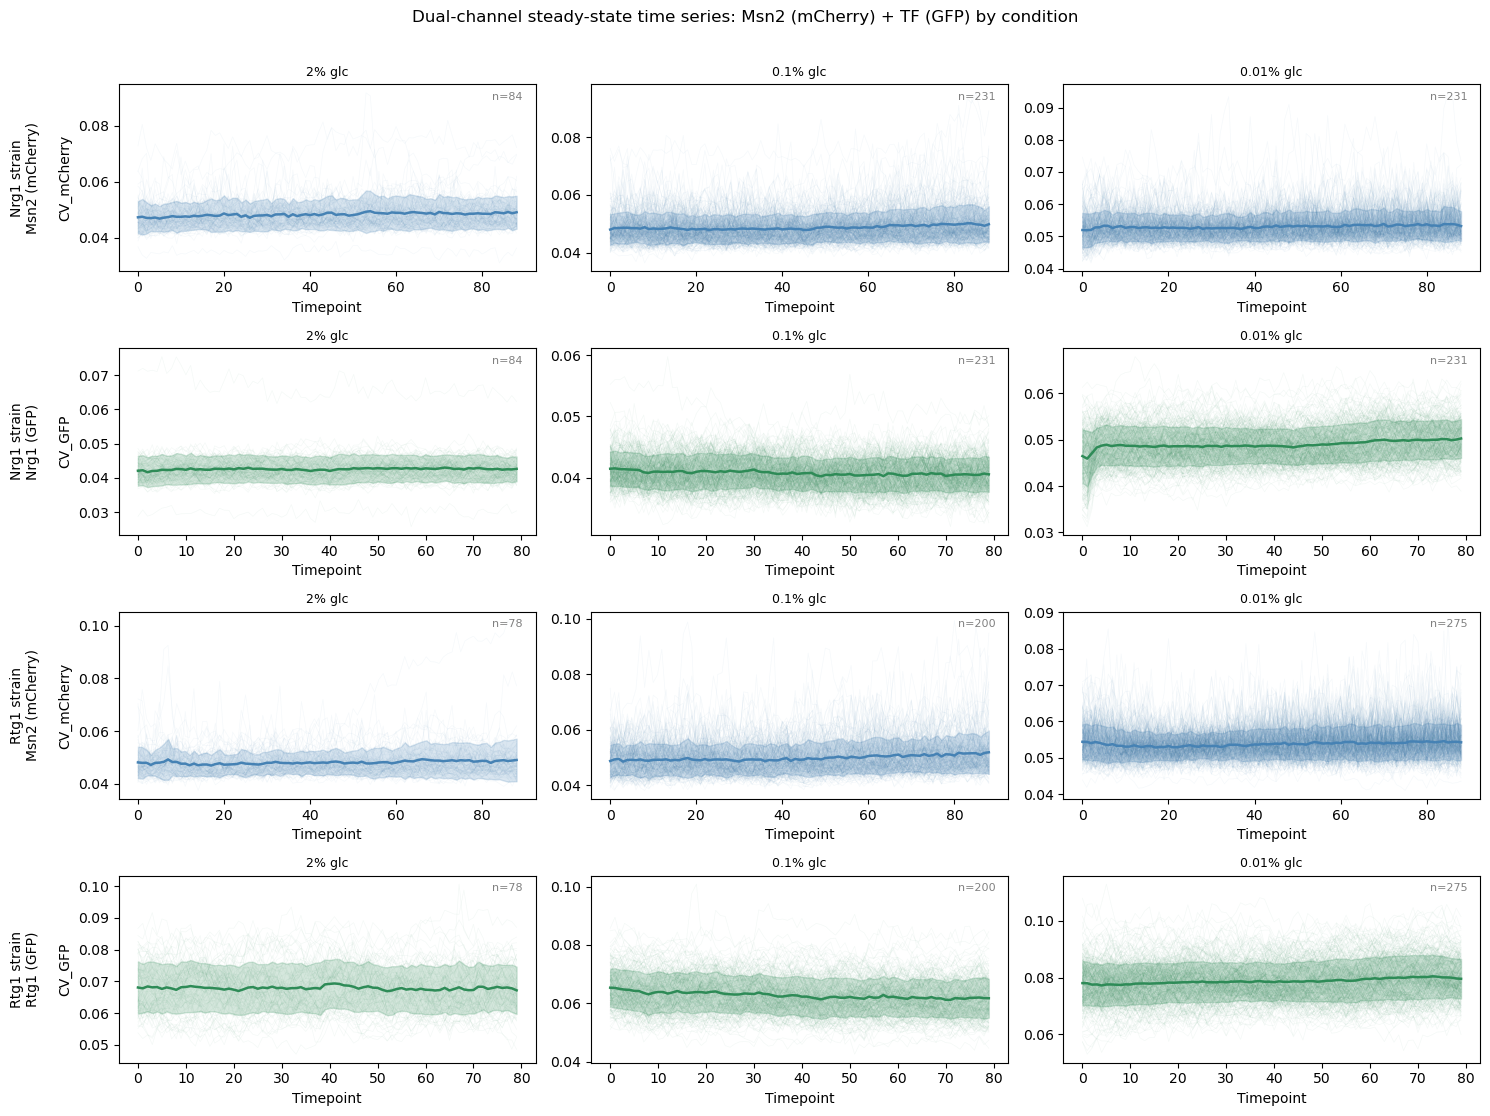

In [4]:
# ── Time series overview: both channels, each TF under each condition ────────
tfs        = ["Nrg1", "Rtg1"]
conditions = [0, 1, 2, 3, 4, 5]   # label order: Nrg1 conditions, then Rtg1

# Map label → condition index for column layout
glc_labels = ["2% glc", "0.1% glc", "0.01% glc"]
t_m = np.arange(min_tp_m)
t_g = np.arange(min_tp_g)

fig, axes = plt.subplots(4, 3, figsize=(15, 11), sharey=False, sharex=False)
# Rows: Nrg1-mCherry, Nrg1-GFP, Rtg1-mCherry, Rtg1-GFP

row_info = [
    ("Nrg1", "mCherry", "Msn2 (mCherry)", "steelblue", [0, 1, 2], t_m, X_m),
    ("Nrg1", "GFP",     "Nrg1 (GFP)",     "seagreen",  [0, 1, 2], t_g, X_g),
    ("Rtg1", "mCherry", "Msn2 (mCherry)", "steelblue", [3, 4, 5], t_m, X_m),
    ("Rtg1", "GFP",     "Rtg1 (GFP)",     "seagreen",  [3, 4, 5], t_g, X_g),
]

for row, (tf, ch, ch_label, color, labels, t_ax, X_ch) in enumerate(row_info):
    for col, (lbl, glc) in enumerate(zip(labels, glc_labels)):
        ax   = axes[row, col]
        mask = y == lbl
        X_sub = X_ch[mask]

        for trace in X_sub:
            ax.plot(t_ax, trace, color=color, alpha=0.05, linewidth=0.5)
        if len(X_sub):
            mean = np.nanmean(X_sub, axis=0)
            std  = np.nanstd(X_sub,  axis=0)
            ax.plot(t_ax, mean, color=color, linewidth=1.8)
            ax.fill_between(t_ax, mean - std, mean + std, color=color, alpha=0.2)

        ax.set_title(f"{glc}", fontsize=9)
        ax.set_xlabel("Timepoint")
        if col == 0:
            ax.set_ylabel(f"{tf} strain\n{ch_label}\n\nCV_{ch}")
        ax.text(0.97, 0.96, f"n={mask.sum()}", transform=ax.transAxes,
                ha="right", va="top", fontsize=8, color="gray")

fig.suptitle("Dual-channel steady-state time series: Msn2 (mCherry) + TF (GFP) by condition",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 2. Preprocessing: NaN Fill, Balance & Normalise

In [5]:
def fill_nans(X):
    X = X.copy()
    for i in range(X.shape[0]):
        row = pd.Series(X[i])
        row = row.interpolate().ffill().bfill()
        X[i] = row.values
    col_medians = np.nanmedian(X, axis=0)
    nan_mask = np.isnan(X)
    X[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])
    return X

def batch_wise_normalize(X, mean=None, std=None):
    """Z-score per timepoint. Fit on train, apply to test."""
    if mean is None:
        mean = X.mean(axis=0, keepdims=True)
        std  = X.std( axis=0, keepdims=True) + 1e-8
    return (X - mean) / std, mean, std

# Fill NaNs in each channel separately, then recombine
X_m_clean = fill_nans(X_m)
X_g_clean = fill_nans(X_g)
X_clean   = np.concatenate([X_m_clean, X_g_clean], axis=1)
print(f"NaN remaining: {np.isnan(X_clean).sum()}")

# Balance to minority class
min_count = min(np.sum(y == lbl) for lbl in label_names)
print(f"Balancing to {min_count} samples per class")

rng = np.random.default_rng(42)
bal_idx = np.concatenate([
    rng.choice(np.where(y == lbl)[0], size=min_count, replace=False)
    for lbl in sorted(label_names)
])

X_m_bal = X_m_clean[bal_idx]
X_g_bal = X_g_clean[bal_idx]
y_bal   = y[bal_idx]

# Split first, then normalise each channel independently using train stats
(X_m_train, X_m_test,
 X_g_train, X_g_test,
 y_train, y_test) = [None]*6

splits = train_test_split(X_m_bal, X_g_bal, y_bal,
                          test_size=0.2, random_state=42, stratify=y_bal)
X_m_train, X_m_test, X_g_train, X_g_test, y_train, y_test = splits

X_m_train, m_mean, m_std = batch_wise_normalize(X_m_train)
X_m_test,  _,      _     = batch_wise_normalize(X_m_test,  m_mean, m_std)
X_g_train, g_mean, g_std = batch_wise_normalize(X_g_train)
X_g_test,  _,      _     = batch_wise_normalize(X_g_test,  g_mean, g_std)

print(f"Balanced: {len(y_bal)} cells  |  class counts: {np.bincount(y_bal)}")
print(f"Train {len(y_train)}  |  Test {len(y_test)}")
print("Normalisation: batch-wise z-score fit on train per channel, applied to test")

NaN remaining: 0
Balancing to 78 samples per class
Balanced: 468 cells  |  class counts: [78 78 78 78 78 78]
Train 374  |  Test 94
Normalisation: batch-wise z-score fit on train per channel, applied to test


## 3. SimCLR Model Registry & Dual-Channel Encoding

Each channel (mCherry, GFP) is encoded separately by the frozen backbone, then the two embedding vectors are concatenated before the SVM.

In [6]:
NORM_OVERRIDES = {
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260303_170229_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_125632_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_132219_model": "joint",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_125550_model": "global",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_165118_model": "joint",
}

def parse_arch_from_name(name):
    d_model    = int(re.search(r"_D(\d+)", name).group(1))
    nhead      = int(re.search(r"_H(\d+)", name).group(1))
    num_layers = int(re.search(r"_L(\d+)", name).group(1))
    return dict(input_size=1, d_model=d_model, nhead=nhead,
                num_layers=num_layers, dropout=0.01, use_conv1d=False)

def make_short_label(path):
    exp    = path.parts[-2]
    stem   = path.stem
    exp_id = re.search(r"IY\d+", exp).group()
    bs     = re.search(r"_b(\d+)", stem)
    bs     = f"b{bs.group(1)}" if bs else ""
    dm     = re.search(r"_D(\d+)", stem)
    dm     = f"D{dm.group(1)}" if dm else ""
    if   "batch-wise" in stem:   norm = "batch"
    elif "global"     in stem:   norm = "global"
    elif "joint"      in stem:   norm = "joint"
    elif "mixed"      in stem:   norm = "mixed"
    elif stem in NORM_OVERRIDES: norm = NORM_OVERRIDES[stem]
    else:                        norm = "inst"
    return f"{exp_id}-{norm} {bs} {dm}".strip()

CKPT_DIRS = ["EXP-26-IY017", "EXP-26-IY022", "EXP-26-IY023"]
MODEL_REGISTRY = []
for d in CKPT_DIRS:
    for p in sorted((EXP_DIR / d).glob("*.pth")):
        MODEL_REGISTRY.append((p, make_short_label(p)))

print(f"Found {len(MODEL_REGISTRY)} checkpoints:")
for p, lbl in MODEL_REGISTRY:
    arch = parse_arch_from_name(p.name)
    print(f"  [{p.parts[-2]}]  {lbl:<42s}  d_model={arch['d_model']}")

# ── Dual-channel encoding: encode each channel separately, concatenate ───────
def load_model(ckpt_path, device):
    kwargs = parse_arch_from_name(ckpt_path.name)
    model  = SSL_Transformer(**kwargs)
    state_dict = torch.load(ckpt_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    return model.to(device).eval()

def encode_dataset(model, X_np, device, batch_size=256):
    embeddings = []
    with torch.no_grad():
        for start in range(0, len(X_np), batch_size):
            chunk = X_np[start : start + batch_size]
            x = torch.from_numpy(chunk).float().unsqueeze(-1).to(device)
            embeddings.append(model.backbone.encode(x).cpu().numpy())
    return np.concatenate(embeddings, axis=0)

def run_simclr_svm_dual(model, Xm_tr, Xm_te, Xg_tr, Xg_te, y_tr, y_te, device):
    """Encode mCherry and GFP separately, concatenate embeddings, then SVM."""
    Zm_tr = encode_dataset(model, Xm_tr, device)
    Zm_te = encode_dataset(model, Xm_te, device)
    Zg_tr = encode_dataset(model, Xg_tr, device)
    Zg_te = encode_dataset(model, Xg_te, device)
    Z_tr  = np.concatenate([Zm_tr, Zg_tr], axis=1)
    Z_te  = np.concatenate([Zm_te, Zg_te], axis=1)
    scaler   = StandardScaler()
    Z_tr_sc  = scaler.fit_transform(Z_tr)
    Z_te_sc  = scaler.transform(Z_te)
    clf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
    clf.fit(Z_tr_sc, y_tr)
    y_pred = clf.predict(Z_te_sc)
    return accuracy_score(y_te, y_pred), y_pred

Found 30 checkpoints:
  [EXP-26-IY017]  IY017-inst b100 D128                        d_model=128
  [EXP-26-IY017]  IY017-inst b100 D128                        d_model=128
  [EXP-26-IY017]  IY017-inst b1024 D16                        d_model=16
  [EXP-26-IY017]  IY017-inst b1024 D16                        d_model=16
  [EXP-26-IY017]  IY017-inst b128 D16                         d_model=16
  [EXP-26-IY017]  IY017-inst b16 D16                          d_model=16
  [EXP-26-IY017]  IY017-inst b16 D16                          d_model=16
  [EXP-26-IY017]  IY017-inst b2048 D16                        d_model=16
  [EXP-26-IY017]  IY017-inst b256 D16                         d_model=16
  [EXP-26-IY017]  IY017-inst b32 D128                         d_model=128
  [EXP-26-IY017]  IY017-inst b4096 D16                        d_model=16
  [EXP-26-IY017]  IY017-inst b4096 D16                        d_model=16
  [EXP-26-IY017]  IY017-inst b512 D16                         d_model=16
  [EXP-26-IY017]  IY017-in

## 4. Run All Models

In [7]:
results = {}

for ckpt_path, label in MODEL_REGISTRY:
    print(f"\n{'='*60}")
    print(f"Model: {label}")
    print(f"  {ckpt_path.name}")
    try:
        model = load_model(ckpt_path, DEVICE)
        acc, y_pred = run_simclr_svm_dual(
            model, X_m_train, X_m_test, X_g_train, X_g_test, y_train, y_test, DEVICE)
        results[label] = (acc, y_pred)
        print(f"  Accuracy: {acc:.4f}")
    except Exception as e:
        print(f"  FAILED: {e}")
        results[label] = (float("nan"), None)


Model: IY017-inst b100 D128
  IY017_simCLR_b100_lr0.01_L2_H4_D128_model.pth
  Accuracy: 0.6596

Model: IY017-inst b100 D128
  IY017_simCLR_b100_lr0.01_d0.01_L2_H4_D128_model.pth
  Accuracy: 0.6915

Model: IY017-inst b1024 D16
  IY017_simCLR_b1024_lr0.01_L2_H4_D16_20260219_164413_model.pth
  Accuracy: 0.7447

Model: IY017-inst b1024 D16
  IY017_simCLR_b1024_lr0.01_L2_H4_D16_20260224_061239_model.pth
  Accuracy: 0.7660

Model: IY017-inst b128 D16
  IY017_simCLR_b128_lr0.01_L2_H4_D16_20260217_151037_model.pth
  Accuracy: 0.7553

Model: IY017-inst b16 D16
  IY017_simCLR_b16_lr0.01_L2_H4_D16_model.pth
  Accuracy: 0.7021

Model: IY017-inst b16 D16
  IY017_simCLR_b16_lr0.01_d0.01_L2_H4_D16_model.pth
  Accuracy: 0.6383

Model: IY017-inst b2048 D16
  IY017_simCLR_b2048_lr0.01_L2_H4_D16_20260220_162432_model.pth
  Accuracy: 0.7128

Model: IY017-inst b256 D16
  IY017_simCLR_b256_lr0.01_L2_H4_D16_20260218_154425_model.pth
  Accuracy: 0.7128

Model: IY017-inst b32 D128
  IY017_simCLR_b32_lr0.01_L2

## 5. Results Visualisation

Best model : IY017-inst b512 D16  (0.7872)
Worst model: IY017-inst b64 D16  (0.5638)
Chance     : 0.1667


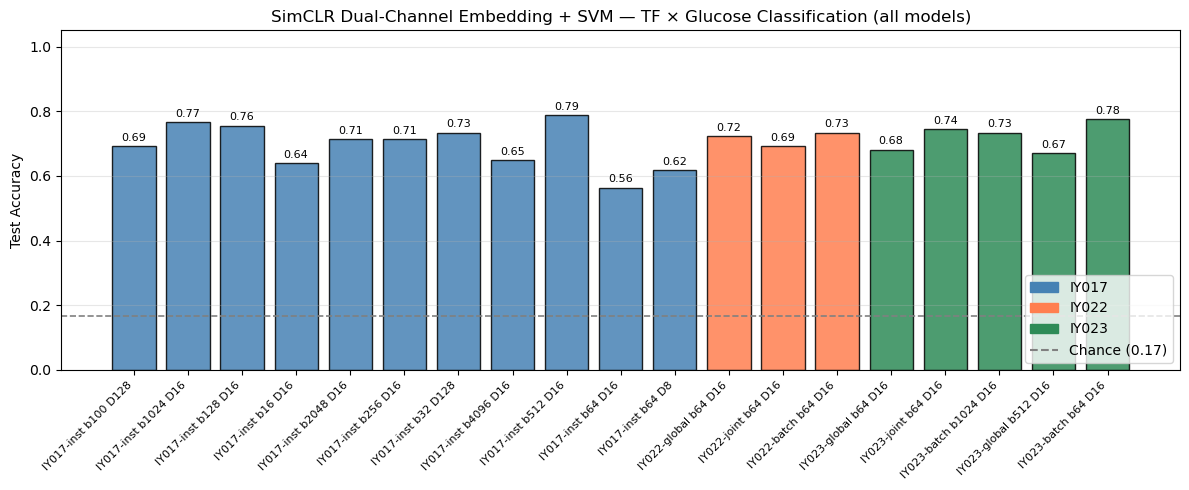


All results:
  IY017-inst b512 D16                           0.7872
  IY023-batch b64 D16                           0.7766
  IY017-inst b1024 D16                          0.7660
  IY017-inst b128 D16                           0.7553
  IY023-joint b64 D16                           0.7447
  IY017-inst b32 D128                           0.7340
  IY022-batch b64 D16                           0.7340
  IY023-batch b1024 D16                         0.7340
  IY022-global b64 D16                          0.7234
  IY017-inst b2048 D16                          0.7128
  IY017-inst b256 D16                           0.7128
  IY017-inst b100 D128                          0.6915
  IY022-joint b64 D16                           0.6915
  IY023-global b64 D16                          0.6809
  IY023-global b512 D16                         0.6702
  IY017-inst b4096 D16                          0.6489
  IY017-inst b16 D16                            0.6383
  IY017-inst b64 D8                             0.6

In [12]:
valid_results = {k: v for k, v in results.items() if not np.isnan(v[0])}
model_labels  = list(valid_results.keys())
accs          = [valid_results[k][0] for k in model_labels]
class_names   = [label_names[i] for i in sorted(label_names)]
chance        = 1 / len(label_names)

color_map = {"IY017": "steelblue", "IY022": "coral", "IY023": "seagreen"}
bar_colors = [color_map.get(lbl.split("-")[0], "gray") for lbl in model_labels]

fig, ax = plt.subplots(figsize=(max(12, len(model_labels) * 0.5 + 2), 5))
bars = ax.bar(range(len(model_labels)), accs, color=bar_colors, alpha=0.85, edgecolor="black")
ax.axhline(chance, color="gray", linestyle="--", linewidth=1.2, label=f"Chance ({chance:.2f})")
ax.set_xticks(range(len(model_labels)))
ax.set_xticklabels(model_labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Test Accuracy")
ax.set_ylim(0, 1.05)
ax.set_title("SimCLR Dual-Channel Embedding + SVM — TF × Glucose Classification (all models)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
# show acuracy values on bars
for bar, acc in zip(bars, accs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f"{acc:.2f}",
            ha="center", va="bottom", fontsize=8)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=k) for k, c in color_map.items()] +
          [plt.Line2D([0],[0], color="gray", linestyle="--", label=f"Chance ({chance:.2f})")], loc="lower right")

best_lbl = max(valid_results, key=lambda k: valid_results[k][0])
best_acc = valid_results[best_lbl][0]
print(f"Best model : {best_lbl}  ({best_acc:.4f})")
print(f"Worst model: {min(valid_results, key=lambda k: valid_results[k][0])}  "
      f"({min(v[0] for v in valid_results.values()):.4f})")
print(f"Chance     : {chance:.4f}")

plt.tight_layout()
plt.savefig("IY021_dual_channel_simclr_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAll results:")
for lbl in sorted(valid_results, key=lambda k: -valid_results[k][0]):
    print(f"  {lbl:<45s} {valid_results[lbl][0]:.4f}")

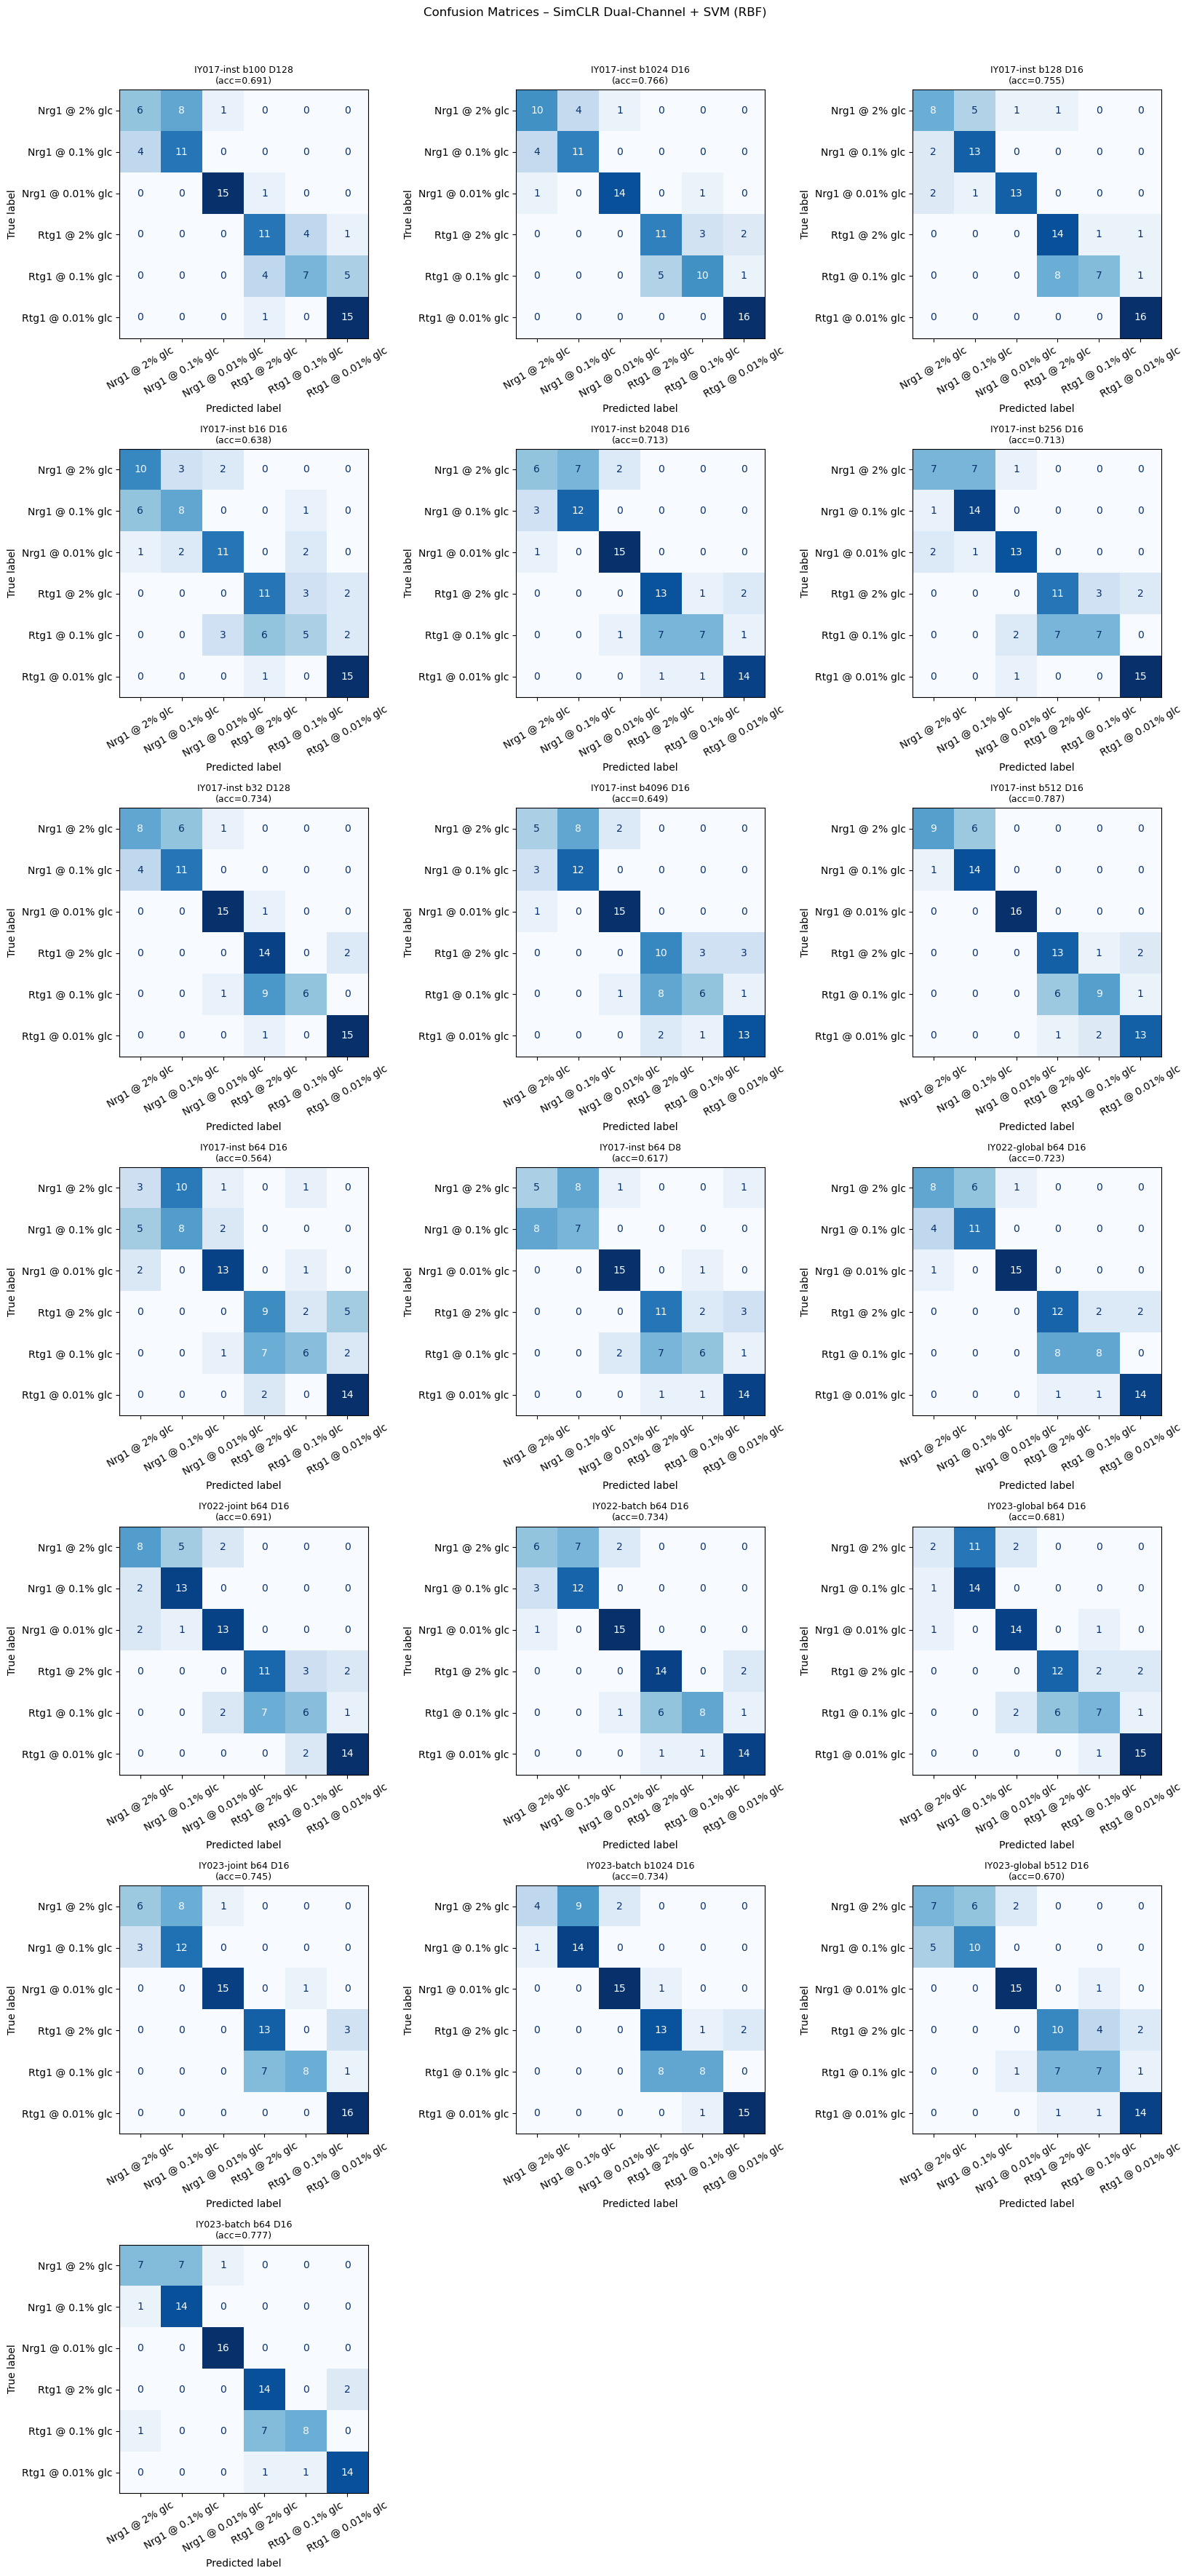

In [9]:
n_valid = len(valid_results)
if n_valid > 0:
    ncols = min(3, n_valid)
    nrows = (n_valid + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5 * nrows))
    axes = np.array(axes).flatten() if n_valid > 1 else [axes]
    for ax, (lbl, (acc, y_pred)) in zip(axes, valid_results.items()):
        if y_pred is not None:
            ConfusionMatrixDisplay.from_predictions(
                y_test, y_pred, display_labels=class_names,
                ax=ax, colorbar=False, cmap="Blues")
            ax.set_title(f"{lbl}\n(acc={acc:.3f})", fontsize=9)
            ax.tick_params(axis="x", rotation=30)
    for ax in axes[len(valid_results):]:
        ax.set_visible(False)
    plt.suptitle("Confusion Matrices – SimCLR Dual-Channel + SVM (RBF)", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()